# Lesson 13 — Overfitting, Underfitting, and the Bias-Variance Idea

## What this notebook does

We take some data with a gentle underlying pattern plus random noise, and try to fit it three ways:

- **Too simple** (a straight line) — it can't bend to the pattern. This is **underfitting**.
- **Just right** (a gentle curve) — it follows the real pattern and ignores the noise.
- **Too complex** (a wildly wiggly curve) — it bends to hit every single training point, including the noise. This is **overfitting**.

We measure each fit's error on the **training data** (the points it learned from) and on a held-out **validation set** (points it never saw), exactly the split we built in Lesson 12. The gap between those two numbers is how we *see* overfitting and underfitting. Then we sweep the complexity from simple to complex and watch the validation error trace a **U-shape** — the picture at the heart of the **bias-variance tradeoff**.

Everything here is a numeric demo (a feature vs. an outcome) so the curves are easy to see; the exact same logic applies to our ticket classifier, just harder to draw.

## Step 1 — Bring in our tools

We need two libraries, both from earlier lessons:

- **NumPy** (Lesson 05) to hold our numbers as arrays and do the math on them.
- **Matplotlib** (Lesson 07) to draw the curves so we can *see* under- and over-fitting.

We also fix the random **seed** (Lesson 10). A seed makes the "random" noise come out the same every run, so your numbers match this walkthrough and the story is repeatable.

In [21]:
import numpy as np                 # arrays and math
import matplotlib.pyplot as plt     # drawing the curves
import os                           # to make a folder for saved plots

np.random.seed(0)                   # fix randomness so results repeat exactly

print("Libraries ready. Random seed fixed at 0.")

Libraries ready. Random seed fixed at 0.


## Step 2 — Make data with a real pattern *plus* noise

To study over- and under-fitting we need data where we already know the truth, so we build it ourselves.

Picture a numeric relationship in our store: as a support ticket gets longer (our input `x`), customer satisfaction (our output `y`) first rises a bit, then drifts back down — a gentle hump. That true relationship is the **signal**: the pattern we *want* the model to learn.

But every real rating also has randomness — the customer's mood, the day, luck. We add that as **noise**: small random wobble on top of the signal. The noise is exactly what a model should *not* try to learn, because it won't repeat for the next customer.

So each data point is **signal + noise**. A good model captures the signal and shrugs off the noise. Underfitting misses even the signal; overfitting chases the noise.

In [22]:
# x is our input feature: 24 evenly spaced values from 0 to 10
x = np.linspace(0, 10, 24)

# The TRUE hidden pattern (the signal). We invent it so we know the right answer.
# A gentle downward hump: rises then falls as x grows.
true_y = 3 + 1.2 * x - 0.15 * x ** 2

# The noise: random wobble, one value per point, average 0, spread 1.5
noise = np.random.normal(0, 1.5, 24)

# What we actually observe = signal + noise
y = true_y + noise

# Show the first few points so we can see signal, noise, and the sum
print("First 5 points (x, true signal, noise, observed y):")
for i in range(5):                                  # walk the first 5 points one by one
    xi = round(float(x[i]), 2)                       # the input value
    si = round(float(true_y[i]), 2)                  # the true signal there
    ni = round(float(noise[i]), 2)                    # the random noise added
    yi = round(float(y[i]), 2)                        # what we observe = signal + noise
    print("  x =", xi, "| signal =", si, "| noise =", ni, "| observed y =", yi)

print("\nTotal points:", len(x))

First 5 points (x, true signal, noise, observed y):
  x = 0.0 | signal = 3.0 | noise = 2.65 | observed y = 5.65
  x = 0.43 | signal = 3.49 | noise = 0.6 | observed y = 4.09
  x = 0.87 | signal = 3.93 | noise = 1.47 | observed y = 5.4
  x = 1.3 | signal = 4.31 | noise = 3.36 | observed y = 7.67
  x = 1.74 | signal = 4.63 | noise = 2.8 | observed y = 7.43

Total points: 24


## Step 3 — Split into training and validation (Lesson 12)

Same discipline as last lesson: the model may **learn** only from the training points, and we **judge** it on validation points it never saw.

We hold out every third point as validation (8 points) and keep the rest for training (16 points). We use an explicit loop so you can see exactly which index goes where — no clever one-liner hiding the split.

Holding out *spread-out* points (not just the last chunk) matters here: the validation set covers the whole range of `x`, so it can fairly catch a curve that wiggles wildly between training points.

In [23]:
# Decide which indices are training and which are validation
train_indices = []                      # will hold positions used for learning
val_indices = []                        # will hold positions held out for judging

for i in range(len(x)):                 # look at every point's index in turn
    if i % 3 == 2:                      # every third point (2, 5, 8, ...) is held out
        val_indices.append(i)           # this one goes to validation
    else:                               # all other points
        train_indices.append(i)         # this one goes to training

# Pull out the actual x and y values for each pile using those index lists
x_train = x[train_indices]              # training inputs
y_train = y[train_indices]              # training outputs
x_val = x[val_indices]                  # validation inputs
y_val = y[val_indices]                  # validation outputs

print("Training points:", len(x_train))
print("Validation points:", len(x_val))
print("Validation indices held out:", val_indices)

Training points: 16
Validation points: 8
Validation indices held out: [2, 5, 8, 11, 14, 17, 20, 23]


## Step 4 — How we measure "how wrong" a fit is

We reuse **mean squared error (MSE)** from Lesson 09 — our loss function.

Plain meaning first: for each point, take how far the model's guess is from the real value (the *error*), square it so big misses count much more and the sign doesn't matter, then average those squared misses over all points. **Lower is better; 0 means a perfect fit.**

We write it as an explicit loop so every step is visible: subtract, square, add up, divide by the count.

In [24]:
def mean_squared_error(actual_values, predicted_values):
    # actual_values  = the real y numbers
    # predicted_values = what the model guessed for the same points
    total_squared_error = 0.0                       # running sum of squared misses
    number_of_points = len(actual_values)           # how many points we're scoring

    for i in range(number_of_points):               # go point by point
        error = actual_values[i] - predicted_values[i]   # how far off this guess is
        squared_error = error * error               # square it (big misses hurt more)
        total_squared_error = total_squared_error + squared_error  # add to the running sum

    average_squared_error = total_squared_error / number_of_points  # average the misses
    return average_squared_error

# Quick sanity check: a perfect guess should score 0
demo_actual = [2.0, 4.0, 6.0]
demo_perfect = [2.0, 4.0, 6.0]
demo_off = [3.0, 4.0, 6.0]                          # first guess is 1 too high
print("MSE of a perfect guess:", mean_squared_error(demo_actual, demo_perfect))
print("MSE with one point off by 1:", mean_squared_error(demo_actual, demo_off))

MSE of a perfect guess: 0.0
MSE with one point off by 1: 0.3333333333333333


## Step 5 — "Complexity" = how bendy the curve is allowed to be

Our model is a **polynomial** — a curve described by a formula like `y = a + b·x + c·x² + ...`. The **degree** is the highest power of `x` we allow, and it controls how bendy the curve can be:

- **Degree 1** → a straight line. One bend allowed: none. Very simple.
- **Degree 3** → a gentle S/hump. A few bends. Just enough for our hump-shaped signal.
- **Degree 15** → up to fifteen bends. Wildly flexible — flexible enough to snake through every training point.

Two NumPy helpers do the work (a library detail worth confirming in the current NumPy docs):

- `np.polyfit(x_train, y_train, degree)` finds the best coefficients (`a, b, c, ...`) of that degree for the training points. This *is* the "learning" step — it sets the model's parameters from data.
- `np.polyval(coefficients, x)` uses those coefficients to predict `y` for any `x`.

Higher degree can *never* fit the training points worse — more bends can only hug them tighter. The question is what that does to the **validation** points it didn't see.

In [25]:
# The three complexities we want to compare
degrees_to_try = [1, 3, 15]             # too simple, just right, too complex
labels = {1: "TOO SIMPLE (underfit)",   # friendly names for printing
          3: "JUST RIGHT",
          15: "TOO COMPLEX (overfit)"}

fitted_curves = {}                      # remember each degree's coefficients for later plotting

for degree in degrees_to_try:                        # try each complexity in turn
    # LEARN: find best coefficients of this degree using TRAINING points only
    coefficients = np.polyfit(x_train, y_train, degree)
    print("Degree", degree, "coefficients:", coefficients)
    fitted_curves[degree] = coefficients             # save for the plot cell

    # PREDICT on the points the model learned from...
    train_predictions = np.polyval(coefficients, x_train)
    # ...and on the held-out points it never saw
    val_predictions = np.polyval(coefficients, x_val)

    # SCORE both with our MSE (lower = better)
    train_error = mean_squared_error(y_train, train_predictions)
    val_error = mean_squared_error(y_val, val_predictions)

    print("Degree", degree, "-", labels[degree])
    print("   training error (points it learned):", round(train_error, 3))
    print("   validation error (unseen points)  :", round(val_error, 3))
    print("   gap (validation - training)        :", round(val_error - train_error, 3))
    print()

Degree 1 coefficients: [-0.40865934  6.97634852]
Degree 1 - TOO SIMPLE (underfit)
   training error (points it learned): 1.727
   validation error (unseen points)  : 7.325
   gap (validation - training)        : 5.598

Degree 3 coefficients: [ 5.13679602e-03 -1.81521056e-01  8.93278192e-01  5.30787946e+00]
Degree 3 - JUST RIGHT
   training error (points it learned): 0.99
   validation error (unseen points)  : 4.885
   gap (validation - training)        : 3.895

Degree 15 coefficients: [-4.68723911e-06  3.41020755e-04 -1.12409486e-02  2.22049755e-01
 -2.92969576e+00  2.72366993e+01 -1.83405792e+02  9.05254060e+02
 -3.27576097e+03  8.59780492e+03 -1.59913765e+04  2.02315194e+04
 -1.62187258e+04  7.20113121e+03 -1.27384244e+03  5.64606711e+00]
Degree 15 - TOO COMPLEX (overfit)
   training error (points it learned): 0.0
   validation error (unseen points)  : 924397.376
   gap (validation - training)        : 924397.376



## Step 6 — Read those three numbers like a doctor

Two numbers per model — training error and validation error — and the story is in **how they compare**:

- **Underfit (degree 1):** training error is *high* and validation error is *high too*. The line is too stiff to follow even the training points, so it fails everywhere. Both bad = **too simple**. This is called **high bias** — the model is biased toward a shape too plain for the data.

- **Just right (degree 3):** training error is low **and** validation error is about as low. It learned the real hump and stops there. Small gap, both good — this is the model you keep.

- **Overfit (degree 15):** training error is *tiny* (it snakes through almost every training point) but validation error is *large*. It memorised the training noise, which doesn't repeat on new points. **Big gap = overfitting.** This is called **high variance** — the fitted curve swings wildly depending on the exact training points it happened to see.

The single most useful diagnostic: **the gap between training error and validation error.** Small gap, both low = healthy. Both high = underfitting. Low training but high validation = overfitting.

## Step 7 — See it: the three fits drawn over the data

Numbers are convincing, but the picture makes it obvious. We draw:

- the **training points** (dots the model learned from),
- the **validation points** (different marker, the unseen dots),
- the **true signal** (the hump we invented), and
- each fitted curve on top.

Watch the degree-1 line ignore the hump entirely (underfit), the degree-3 curve trace the true hump (just right), and the degree-15 curve thrash up and down to touch training dots while missing the validation dots by a mile (overfit). We save it as a PNG so you can keep it.

Saved: plots/lesson-13-three-fits.png


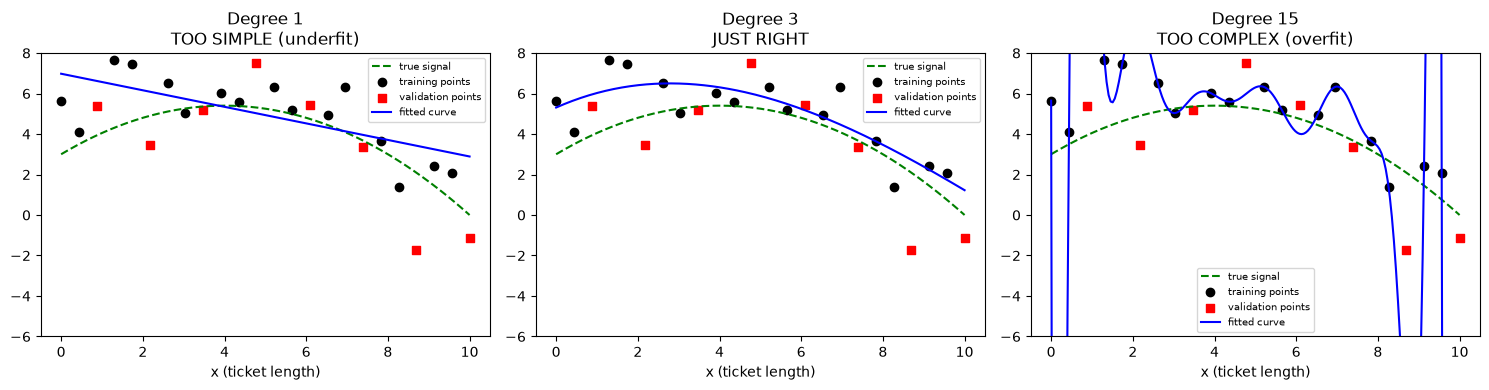

In [26]:
# A smooth, dense line of x-values just for drawing pretty curves
x_smooth = np.linspace(0, 10, 200)                   # 200 points across the range

# One row of three side-by-side plots, one per degree
figure, axes = plt.subplots(1, 3, figsize=(15, 4))

for position in range(len(degrees_to_try)):          # 0, 1, 2 -> which subplot
    degree = degrees_to_try[position]                # the degree for this subplot
    this_plot = axes[position]                       # the subplot to draw on

    # Predict the curve across the smooth x-values using this degree's saved coefficients
    curve_y = np.polyval(fitted_curves[degree], x_smooth)

    # Draw the real signal, the two point sets, and the fitted curve
    this_plot.plot(x_smooth, 3 + 1.2 * x_smooth - 0.15 * x_smooth ** 2,
                   color="green", linestyle="--", label="true signal")
    this_plot.scatter(x_train, y_train, color="black", label="training points")
    this_plot.scatter(x_val, y_val, color="red", marker="s", label="validation points")
    this_plot.plot(x_smooth, curve_y, color="blue", label="fitted curve")

    this_plot.set_title("Degree " + str(degree) + "\n" + labels[degree])
    this_plot.set_ylim(-6, 8)                         # same y-range so plots compare fairly
    this_plot.set_xlabel("x (ticket length)")
    this_plot.legend(fontsize=7)

plt.tight_layout()

# Save the figure next to this notebook, inside a plots/ folder
os.makedirs("plots", exist_ok=True)                  # make the folder if missing
plt.savefig("plots/lesson-13-three-fits.png", dpi=100)
print("Saved: plots/lesson-13-three-fits.png")
plt.show()

## Step 8 — Sweep every complexity and watch the U-shape

Three degrees told the story; now we sweep degree 1 through 15 and record both errors at each step. This draws the famous **bias-variance picture**:

- **Training error** slides steadily *down* as complexity rises — more bends always hug the training points tighter. On its own, this number is a liar: it keeps improving even while the model gets worse for real use.
- **Validation error** goes *down, bottoms out, then climbs back up* — a **U-shape**. The bottom of that U is the sweet spot: complex enough to catch the signal (bias falling), not so complex it chases noise (variance rising).

The best degree is the one at the **lowest validation error**, not the lowest training error. That is the whole game.

In [27]:
all_degrees = list(range(1, 16))        # 1, 2, 3, ..., 15
train_errors = []                       # training error at each degree
val_errors = []                         # validation error at each degree

for degree in all_degrees:                           # try every complexity
    coefficients = np.polyfit(x_train, y_train, degree)      # learn on training only
    train_predictions = np.polyval(coefficients, x_train)   # predict on training points
    val_predictions = np.polyval(coefficients, x_val)       # predict on unseen points

    train_error = mean_squared_error(y_train, train_predictions)
    val_error = mean_squared_error(y_val, val_predictions)

    train_errors.append(train_error)                 # remember for the plot
    val_errors.append(val_error)

    print("degree", degree,
          "| train error", round(train_error, 3),
          "| validation error", round(val_error, 3))

# Find the degree with the LOWEST validation error, using a plain loop (no min/key trick)
best_degree = all_degrees[0]            # assume the first is best to start
best_val_error = val_errors[0]
for i in range(len(all_degrees)):       # check each degree
    if val_errors[i] < best_val_error:  # found a lower validation error?
        best_val_error = val_errors[i]  # remember the new best score
        best_degree = all_degrees[i]    # and which degree gave it

print("\nBest degree by validation error:", best_degree,
      "(validation error", round(best_val_error, 3), ")")

degree 1 | train error 1.727 | validation error 7.325
degree 2 | train error 1.001 | validation error 4.632
degree 3 | train error 0.99 | validation error 4.885
degree 4 | train error 0.982 | validation error 4.929
degree 5 | train error 0.772 | validation error 6.387
degree 6 | train error 0.668 | validation error 10.753
degree 7 | train error 0.495 | validation error 4.799
degree 8 | train error 0.457 | validation error 7.872
degree 9 | train error 0.202 | validation error 12.145
degree 10 | train error 0.119 | validation error 102.903
degree 11 | train error 0.1 | validation error 274.534
degree 12 | train error 0.073 | validation error 20.353
degree 13 | train error 0.066 | validation error 1072.353
degree 14 | train error 0.03 | validation error 86559.061
degree 15 | train error 0.0 | validation error 924397.376

Best degree by validation error: 2 (validation error 4.632 )


Saved: plots/lesson-13-bias-variance-curve.png


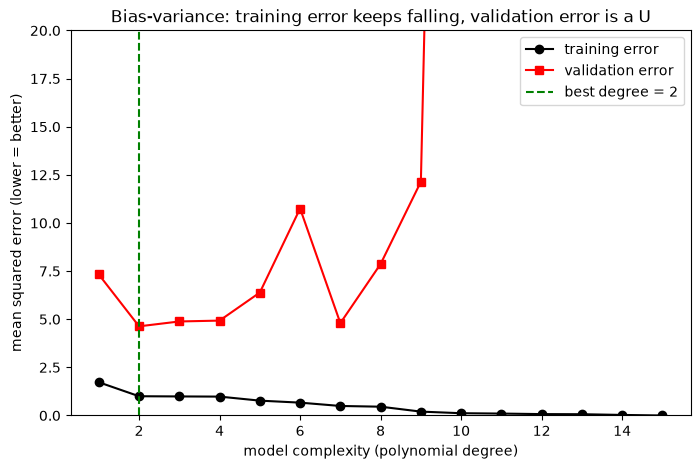

In [28]:
# Draw the two error curves against complexity
plt.figure(figsize=(8, 5))
plt.plot(all_degrees, train_errors, marker="o", color="black", label="training error")
plt.plot(all_degrees, val_errors, marker="s", color="red", label="validation error")

# Mark the sweet spot (lowest validation error) with a vertical line
plt.axvline(best_degree, color="green", linestyle="--", label="best degree = " + str(best_degree))

plt.title("Bias-variance: training error keeps falling, validation error is a U")
plt.xlabel("model complexity (polynomial degree)")
plt.ylabel("mean squared error (lower = better)")
plt.ylim(0, 20)                          # clip the huge overfit spike so the U stays readable
plt.legend()

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/lesson-13-bias-variance-curve.png", dpi=100)
print("Saved: plots/lesson-13-bias-variance-curve.png")
plt.show()

## Step 9 — The idealized textbook picture, drawn cleanly

The real sweep above is a bit jumpy because we only have 8 validation points — real data always wobbles. So here we draw the **clean, idealized** version of the same idea (the ASCII sketch from the lesson notes, made real): two smooth made-up curves that show the *shape* every bias-variance picture has.

These curves are not measured from data — we build them by hand to illustrate the pattern:

- **Training error** = a curve that always falls toward zero as complexity grows.
- **Validation error** = **bias** (high when too simple, shrinks with complexity) **+ variance** (near zero when simple, grows when too complex) **+ irreducible noise** (a floor no model can beat). Add those three and you get the **U**.

The lowest point of the red U is the sweet spot; left of it is underfitting, right of it is overfitting.

Saved: plots/lesson-13-bias-variance-schematic.png
Sweet spot sits at complexity ~ 3.3 (bottom of the U)


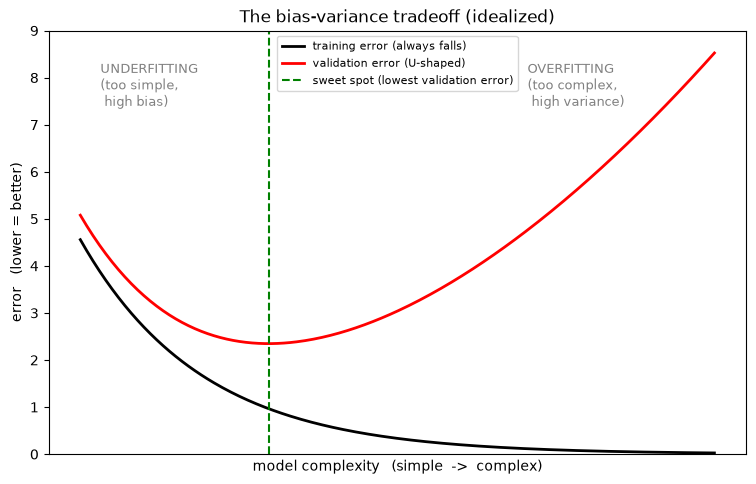

In [29]:
# A schematic complexity axis (this is a hand-built illustration, NOT real data)
complexity = np.linspace(0.5, 10, 300)       # left = simple model, right = complex model

# Training error: always falls toward zero as complexity grows (more bends hug the data)
train_error_curve = 6 * np.exp(-0.55 * complexity)

# The two ingredients of error on NEW (validation) data:
bias_part = 6 * np.exp(-0.55 * complexity)   # big when too simple, shrinks as complexity grows
variance_part = 0.08 * complexity ** 2       # ~0 when simple, grows fast when too complex
irreducible_noise = 0.5                       # a floor no model can ever beat

# Validation error = bias + variance + irreducible noise  ->  this gives the U-shape
val_error_curve = bias_part + variance_part + irreducible_noise

# Find the sweet spot: the complexity with the LOWEST validation error (plain loop, no min/key)
best_index = 0                                # assume the first point is lowest to start
best_value = val_error_curve[0]
for i in range(len(complexity)):             # scan every point on the curve
    if val_error_curve[i] < best_value:      # found a lower validation error?
        best_value = val_error_curve[i]      # remember the new lowest value
        best_index = i                       # and where it happened
best_complexity = complexity[best_index]     # the complexity at the bottom of the U

# Draw the idealized picture
plt.figure(figsize=(9, 5.5))
plt.plot(complexity, train_error_curve, color="black", linewidth=2,
         label="training error (always falls)")
plt.plot(complexity, val_error_curve, color="red", linewidth=2,
         label="validation error (U-shaped)")
plt.axvline(best_complexity, color="green", linestyle="--",
            label="sweet spot (lowest validation error)")

# Label the two danger zones on either side of the sweet spot
plt.text(0.8, 7.4, "UNDERFITTING\n(too simple,\n high bias)", color="gray", fontsize=9)
plt.text(7.2, 7.4, "OVERFITTING\n(too complex,\n high variance)", color="gray", fontsize=9)

plt.title("The bias-variance tradeoff (idealized)")
plt.xlabel("model complexity   (simple  ->  complex)")
plt.ylabel("error   (lower = better)")
plt.ylim(0, 9)
plt.xticks([])                               # schematic: the exact complexity numbers don't matter
plt.legend(loc="upper center", fontsize=8)

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/lesson-13-bias-variance-schematic.png", dpi=100)
print("Saved: plots/lesson-13-bias-variance-schematic.png")
print("Sweet spot sits at complexity ~", round(float(best_complexity), 1), "(bottom of the U)")
plt.show()

## What to carry away

- **Underfitting = too simple = high bias.** Both training and validation error are high. Fix: give the model more power (more complexity, better features, train longer).
- **Overfitting = too complex = high variance.** Training error is tiny but validation error is high. Fix: make the model simpler, add more data, or hold it back (we'll meet regularization and other brakes in the deep-learning chapters).
- **The gap between training and validation error is your diagnostic tool** — and it's exactly why we built the train/validation split in Lesson 12. Without held-out data, you can't even see overfitting.
- **The bias-variance tradeoff** is the balancing act: too far either way hurts on new data. The best model sits at the bottom of the validation-error U.

Next lesson we start building *real* algorithms that walk down this tradeoff on purpose — beginning with linear regression.